In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os
os.chdir(r'C:\Users\astha\imdb-predictor')
os.listdir()

['explore.py', 'IMDb Movies India.csv', 'movies.csv', 'venv']

In [11]:
with open('movies.csv', 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        print(line)
        if i == 5:
            break

Title,Year,Genre,Rating,Duration,Director,Votes,Revenue

The Shawshank Redemption,1994,Drama,9.3,142,Frank Darabont,2500000,28341469

The Dark Knight,2008,Action/Crime/Drama,9.0,152,Christopher Nolan,2800000,1005045358

#Homecoming,(2021),90 min,"Drama, Musical",,,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana

#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor

...And Once Again,(2010),105 min,Drama,,,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali



In [6]:
df = pd.read_csv('movies.csv', encoding='latin1',
                 names=['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3'],
                 skiprows=1,
                 on_bad_lines='skip')
print(df.shape)
df.head()

(15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,The Shawshank Redemption,1994,Drama,9.3,142.0,Frank Darabont,2500000,28341469,NaN,NaN
1,The Dark Knight,2008,Action/Crime/Drama,9.0,152.0,Christopher Nolan,2800000,1005045358,NaN,NaN
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [7]:
df= df.dropna(subset=['Rating'])

In [14]:
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

In [15]:
df['Duration'] = df['Duration'].str.extract(r'(\d+)').astype(float)

In [18]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

In [19]:
for col in ['Duration','Votes']:
    df[col]= df[col].fillna(df[col].median())

In [20]:
df['log_votes'] = np.log1p(df['Votes'])
print(df.shape)
df.head()

(7920, 11)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,log_votes
0,The Shawshank Redemption,1994.0,134.5,9.3,142.0,35.0,2500000,28341469,NaN,NaN,3.583519
1,The Dark Knight,2008.0,134.5,9.0,152.0,35.0,2800000,1005045358,NaN,NaN,3.583519
3,#Yaaram,NaN,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,3.583519
5,...Aur Pyaar Ho Gaya,NaN,147.0,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,6.719013
6,...Yahaan,NaN,142.0,"Drama, Romance, War",7.4,35.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,3.583519


In [22]:

df['movie_age'] = 2024 - df['Year'].fillna(df['Year'].median())


top_genres = ['Drama', 'Comedy', 'Thriller', 'Action',
              'Romance', 'Crime', 'Horror', 'Documentary',
              'Adventure', 'Biography']

for genre in top_genres:
    df[f'genre_{genre.lower()}'] = df['Genre'].str.contains(
        genre, na=False
    ).astype(int)



df['genre_count'] = df['Genre'].str.split(',').str.len().fillna(1)

print(df.shape)
df.head()

(7920, 23)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,...,genre_comedy,genre_thriller,genre_action,genre_romance,genre_crime,genre_horror,genre_documentary,genre_adventure,genre_biography,genre_count
0,The Shawshank Redemption,1994.0,134.5,9.3,142.0,35.0,2500000,28341469,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1.0
1,The Dark Knight,2008.0,134.5,9.0,152.0,35.0,2800000,1005045358,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1.0
3,#Yaaram,NaN,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,...,1,0,0,1,0,0,0,0,0,2.0
5,...Aur Pyaar Ho Gaya,NaN,147.0,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,...,1,0,0,0,0,0,0,0,0,3.0
6,...Yahaan,NaN,142.0,"Drama, Romance, War",7.4,35.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,...,0,0,0,1,0,0,0,0,0,3.0


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Select only the columns we need for training
features = [
    'log_votes', 'Duration', 'movie_age',
    'genre_count', 'genre_drama', 'genre_comedy',
    'genre_thriller', 'genre_action', 'genre_romance',
    'genre_crime', 'genre_horror', 'genre_documentary',
    'genre_adventure', 'genre_biography'
]

X = df[features]
y = df['Rating']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

print("Training done!")
print(f"Training on {len(X_train)} movies")
print(f"Testing on  {len(X_test)} movies")

Training done!
Training on 6336 movies
Testing on  1584 movies


In [31]:
# Fix the column swap issue
df2 = df2[df2['Rating'] <= 10]
df2 = df2[df2['Rating'] >= 1]

print(df2.shape)
print(df2['Rating'].describe())

(7919, 23)
count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64


MAE : 0.856
R²  : 0.324
On average prediction is off by 0.86 rating points


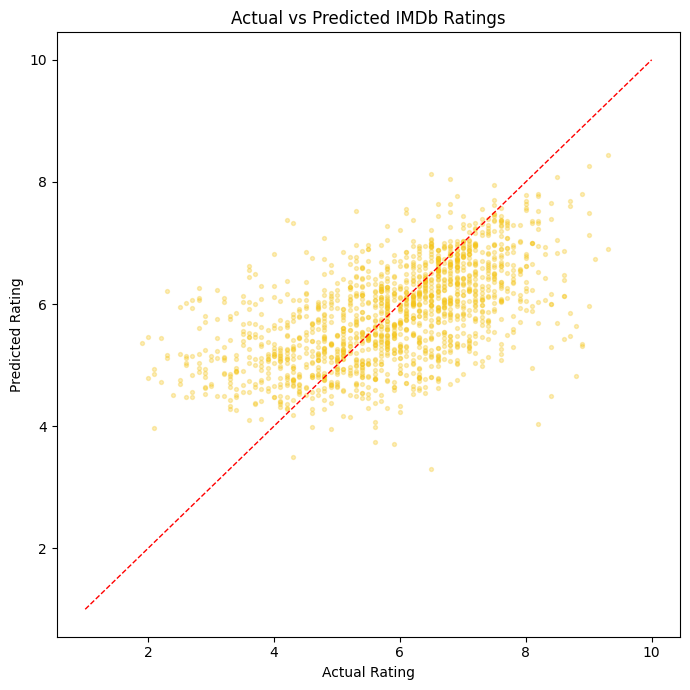

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

features = [
    'log_votes', 'Duration', 'movie_age', 'genre_count',
    'genre_drama', 'genre_comedy', 'genre_thriller', 'genre_action',
    'genre_romance', 'genre_crime', 'genre_horror', 'genre_documentary',
    'genre_adventure', 'genre_biography'
]

X = df2[features]
y = df2['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=200, max_depth=12,
                               min_samples_leaf=5, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")
print(f"On average prediction is off by {mae:.2f} rating points")

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.3, s=8, color='#f5c518')
plt.plot([1, 10], [1, 10], 'r--', lw=1)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted IMDb Ratings')
plt.tight_layout()
plt.show()